<a href="https://colab.research.google.com/github/Nidhisha00/AIML-10days-Internship/blob/main/Day4/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
from PIL import Image, ImageEnhance, ImageOps
import zipfile
import os
import cv2
import pandas as pd
import numpy as np

In [38]:
zip_path = "/content/archive.zip"   # Upload your dataset ZIP file
extract_path = "extracted_images"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total Images Loaded:", len(images))

Total Images Loaded: 813


In [39]:
images = images[:100]
print("Total Images Selected:", len(images))

Total Images Selected: 100


Task1

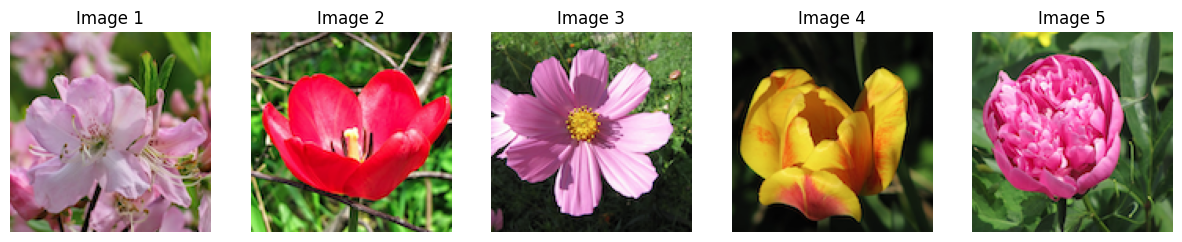

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

task2

In [41]:
image_info = []

for i, img in enumerate(images):
    height, width, channels = img.shape
    image_info.append([i+1, height, width, channels])

df = pd.DataFrame(
    image_info,
    columns=["Image_No", "Height", "Width", "Channels"]
)

print(df)

    Image_No  Height  Width  Channels
0          1     128    128         3
1          2     128    128         3
2          3     128    128         3
3          4     128    128         3
4          5     128    128         3
..       ...     ...    ...       ...
95        96     128    128         3
96        97     128    128         3
97        98     128    128         3
98        99     128    128         3
99       100     128    128         3

[100 rows x 4 columns]


task3

In [42]:
resized_images = []

for img in images:
    resized_img = cv2.resize(img, (224, 224))
    resized_images.append(resized_img)

print("Resized Images:", len(resized_images))

Resized Images: 100


### Displaying a few resized images

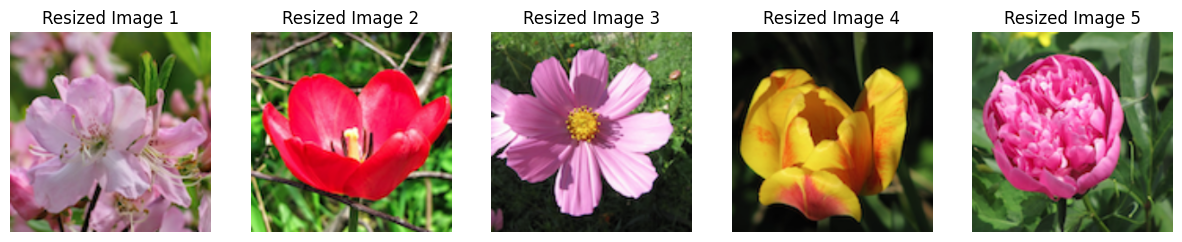

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)

    plt.imshow(cv2.cvtColor(resized_images[i], cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Resized Image {i+1}")

plt.show()

task4

In [44]:
grayscale_images = []

for img in resized_images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    grayscale_images.append(gray)

print("Grayscale Images:", len(grayscale_images))

hsv_images = []

for img in resized_images:
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_images.append(hsv)

print("HSV Images:", len(hsv_images))


Grayscale Images: 100
HSV Images: 100


### Displaying a few grayscale images

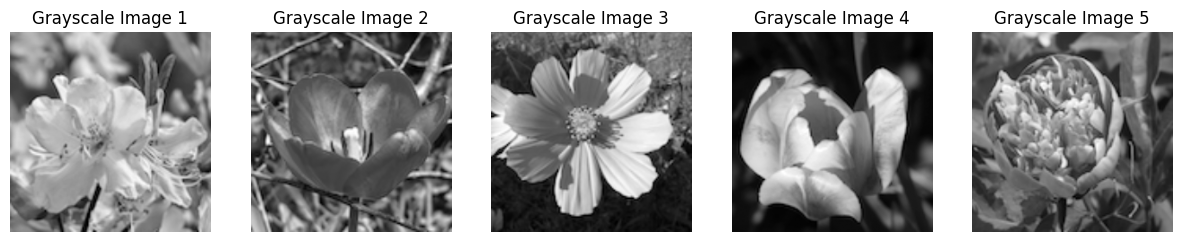

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(grayscale_images[i], cmap='gray')
    plt.axis("off")
    plt.title(f"Grayscale Image {i+1}")

plt.show()

### Displaying a few HSV images (converted to RGB for visualization)

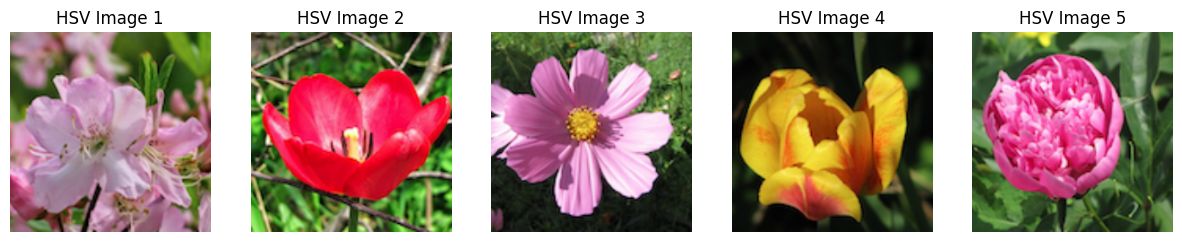

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)

    plt.imshow(cv2.cvtColor(hsv_images[i], cv2.COLOR_HSV2RGB))
    plt.axis("off")
    plt.title(f"HSV Image {i+1}")

plt.show()

task5

In [47]:
normalized_images = []

for img in resized_images:
    normalized = img / 255.0
    normalized_images.append(normalized)

print("Normalized Images:", len(normalized_images))

Normalized Images: 100


### Displaying a few normalized images

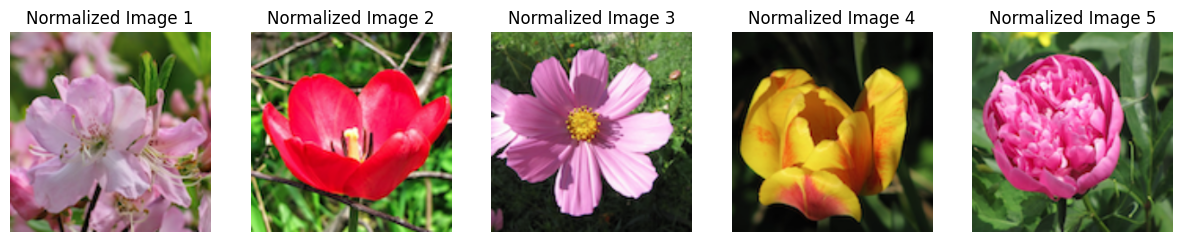

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)

    plt.imshow(cv2.cvtColor((normalized_images[i] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Normalized Image {i+1}")

plt.show()

task9

In [49]:
augmented_dir = "augmented_images"
os.makedirs(augmented_dir, exist_ok=True)

def augment_image(image, image_id):

    image = Image.fromarray(
        cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    )

    # Flip
    flipped = ImageOps.mirror(image)
    flipped.save(
        os.path.join(
            augmented_dir,
            f"flipped_{image_id}.png"
        )
    )

    # Rotation
    rotated = image.rotate(30)
    rotated.save(
        os.path.join(
            augmented_dir,
            f"rotated_{image_id}.png"
        )
    )

    # Brightness
    enhancer = ImageEnhance.Brightness(image)
    brighter = enhancer.enhance(1.5)

    brighter.save(
        os.path.join(
            augmented_dir,
            f"brighter_{image_id}.png"
        )
    )

    # Zoom
    w, h = image.size

    zoomed = image.crop(
        (w*0.1, h*0.1, w*0.9, h*0.9)
    )

    zoomed = zoomed.resize((w, h))

    zoomed.save(
        os.path.join(
            augmented_dir,
            f"zoomed_{image_id}.png"
        )
    )

for i, img in enumerate(resized_images):
    augment_image(img, i)

print("Augmentation Completed")

Augmentation Completed


task10

In [50]:
def preprocess_image(img):

    img = cv2.resize(img, (224, 224))

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = img / 255.0

    return img

In [51]:
processed_images = []

for img in images:
    processed_images.append(
        preprocess_image(img)
    )

print(
    "Total Processed Images:",
    len(processed_images)
)

Total Processed Images: 100


### Displaying a few processed images

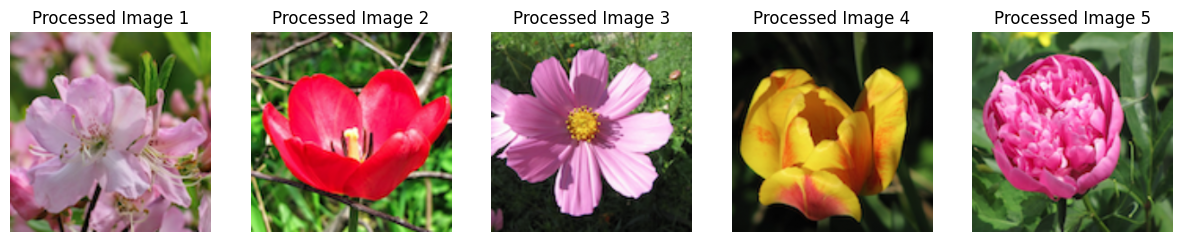

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(processed_images[i]) # processed_images are already in RGB and normalized
    plt.axis("off")
    plt.title(f"Processed Image {i+1}")

plt.show()